# Using PPO to Learn Solar Sail Trajectories

The following code implements a custom Gymnasium environment for a solar sail in low-Earth orbit and trains a PPO model to steer the solar sail towards a debris object.

In [1]:
%pip install numpy matplotlib seaborn scipy gymnasium stable-baselines3 optuna pandas
%pip install "gymnasium[box2d]" "stable_baselines3[extra]"


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /home/abish/Vault/projects-gh/machine-learning/.ml/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /home/abish/Vault/projects-gh/machine-learning/.ml/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

import gymnasium as gym
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sb
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor, load_results

from constants import EARTH_RADIUS
import sailEnv
from utils import meoe2rv, meoe2coe

## Configuration

The following variables control the execution of the algorithm.

In [3]:
INITIAL_SEED = 22                   # used in first training
TUNING_SEED = 222                   # used in hyperparameter tuning
VALIDATION_SEED = 2222              # used when validating tuned models
TRAINING_SEED = 22_222              # used in training the tuned model
TEST_SEED = 222_222                 # used in final test
TIME_STEP =  60                     # seconds per step
REDUCED_EPISODE_TIME = 50*86400     # used in learning, reduced maximum episode time
TOTAL_STEPS = 525_960               # used in learning, equivalent to one year
NO_EPISODES = 30                    # diversity in model learning
MODEL_NAME = "ppo_orbitRaising"
TUNED_MODEL_NAME = "ppo_orbitRaising_optuna"
ENVIRONMENT_NAME = "OrbitRaising-v1" 


if ENVIRONMENT_NAME not in gym.registry:
    print(f"{ENVIRONMENT_NAME} not found in Gymnasium's registry.")

Checkpoints are stored in `checkpoints/`. Plots are stored in `plots/`. Training data is stored in `trainingData/`.

In [4]:
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("trainingData", exist_ok=True)
os.makedirs("plots", exist_ok=True)

Custom plot styling.

In [5]:
def setStyle(fontsize: int) -> None:
    """
        Sets a custom style to Matplotlib graphs.

        PARAMETERS
        ----------
        fontsize: normal font size
    """
    sb.set_theme(style="whitegrid", palette="muted")
    plt.rcParams.update({
        "font.size": fontsize,
        "axes.titlesize": fontsize+2,
        "axes.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "xtick.labelsize": fontsize-1,
        "ytick.labelsize": fontsize-1,
        "font.family": "STIXGeneral",
        "mathtext.fontset": "stix",
    })

setStyle(14)

## Helpers

`randomRun()` employs a random action space sampling.

In [6]:
def randomRun(seed: int, envName: str=ENVIRONMENT_NAME) -> tuple:
    """
        Employs a random action space sampling against a simulated environment.

        PARAMETERS
        ----------
        seed: initializes RNG
        envName: environment name in Gymnasium's registry

        RETURNS
        ----------
        times: time [s]
        rewards: reward per step
        relDists: relative distance per step [m]
        sailAltitudes: sma of the sail per step [m]
        debrisAltitudes: sma of the debris per step [m]
        coneAnglesDeg: cone angle of the sail per step [deg]
        clockAnglesDeg: clock angle of the sail per step [deg]
    """
    env = gym.make(envName, maxTime=30*86400.)
    _, info = env.reset(seed=seed)

    # data to store
    times = [info["time"]]
    rewards = []
    relDists = [info["relDist"]]
    sailAltitudes = [info["sailAltitude"]]
    debrisAltitudes = [info["debrisAltitude"]]
    coneAngles = [env.unwrapped.coneAngle]
    clockAngles = [env.unwrapped.clockAngle]

    while True:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)

        clear_output(wait=True)
        print(f"Full Simulation Progress: {int(100*(env.unwrapped.t/env.unwrapped.maxTime))}%")

        times.append(info["time"])
        rewards.append(reward)
        relDists.append(info["relDist"])
        sailAltitudes.append(info["sailAltitude"])
        debrisAltitudes.append(info["debrisAltitude"])
        coneAngles.append(env.unwrapped.coneAngle)
        clockAngles.append(env.unwrapped.clockAngle)
        
        if terminated or truncated:
            print(f"Stopped simulating. {'Terminated.' if terminated else 'Truncated.'}")
            break

    env.close()

    times = np.array(times)
    rewards = np.array(rewards)
    relDists = np.array(relDists)
    sailAltitudes = np.array(sailAltitudes)
    debrisAltitudes = np.array(debrisAltitudes)
    coneAnglesDeg = np.rad2deg(coneAngles)
    clockAnglesDeg = np.rad2deg(clockAngles)

    return times, rewards, relDists, sailAltitudes, debrisAltitudes, coneAnglesDeg, clockAnglesDeg

`TrackingCallback` is a custom callback to store the relevant data features.

In [ ]:
class TrackingCallback(BaseCallback):
    def __init__(self):
        """
            Custom callback to store relevant data points.
        """
        super().__init__()
        self.relDists = []
        self.sailAltitudes = []
        self.debrisAltitudes = []
        self.coneAngles = []
        self.clockAngles = []

    def _on_step(self) -> bool:
        infos = self.locals["infos"]
        for info in infos:
            if "relDist" in info:
                self.relDists.append(info["relDist"])
            if "sailAltitude" in info:
                self.sailAltitudes.append(info["sailAltitude"])
            if "debrisAltitude" in info:
                self.debrisAltitudes.append(info["debrisAltitude"])
            if "coneAngle" in info:
                self.coneAngles.append(info["coneAngle"])
            if "clockAngle" in info:
                self.clockAngles.append(info["clockAngle"])
            
           

        return True

`trainModel()` creates a PPO instance, trains it and saves it.

In [ ]:
def trainModel(seed: int, maxEpisodeTime: int=REDUCED_EPISODE_TIME, envName: str=ENVIRONMENT_NAME, totalEps: int=NO_EPISODES, modelName: str=MODEL_NAME, **kwargs) -> None:
    """
        Trains a model against a simulated environment.

        PARAMETERS
        ----------
        seed: initializes RNG
        maxEpisodeTime: maximum time per episode
        envName: environment name in Gymnasium's registry
        totalEps: total number of training episodes
        modelName: name of trained model
    """
    env = Monitor(gym.make(envName, maxTime=maxEpisodeTime), filename=f"trainingData/{modelName}")
    env.reset(seed=seed)

    model = PPO("MlpPolicy", env, seed=seed, **kwargs)
    model.learn(total_timesteps=int(maxEpisodeTime/TIME_STEP)*totalEps, progress_bar=True)
    model.save(modelName)

    env.close()

`testModel()` evaluates the performance of an input model on a certain number of episodes.

In [ ]:
def testModel(model, seed: int, envName: str=ENVIRONMENT_NAME, N: int=NO_EPISODES, tuning: bool=False) -> np.ndarray:
    """
        Tests a model against a simulated environment.

        PARAMETERS
        ----------
        model: the trained model
        seed: initializes RNG
        envName: environment name in Gymnasium's registry
        N: number of test episodes
        tuning: whether the function is being called during hyperparameter tuning

        RETURNS
        ----------
        testRewards: reward per episode
    """
    env = gym.make(envName) if not tuning else gym.make(envName, maxTime=REDUCED_EPISODE_TIME)
    testRewards = np.zeros(N)
    testLengths = np.zeros(N)

    for i in range(N):
        obs, _ = env.reset(seed=seed+i)
        testReward = 0
        testLength = 0
        while True:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            testReward += reward
            testLength += 1

            if terminated or truncated:
                break
        testRewards[i] = testReward
        testLengths[i] = testLength

    return testRewards, testLengths

## Random Policy Baseline

The effect of randomly choosing an action.

In [7]:
randomTimes, randomRewards, randomRelDists, randomSailAlts, randomDebrisAlts, randomConeAngles, randomClockAngles = randomRun(seed=INITIAL_SEED)

Full Simulation Progress: 100%


### Reward vs. Steps

Shows the evolution of step rewards.

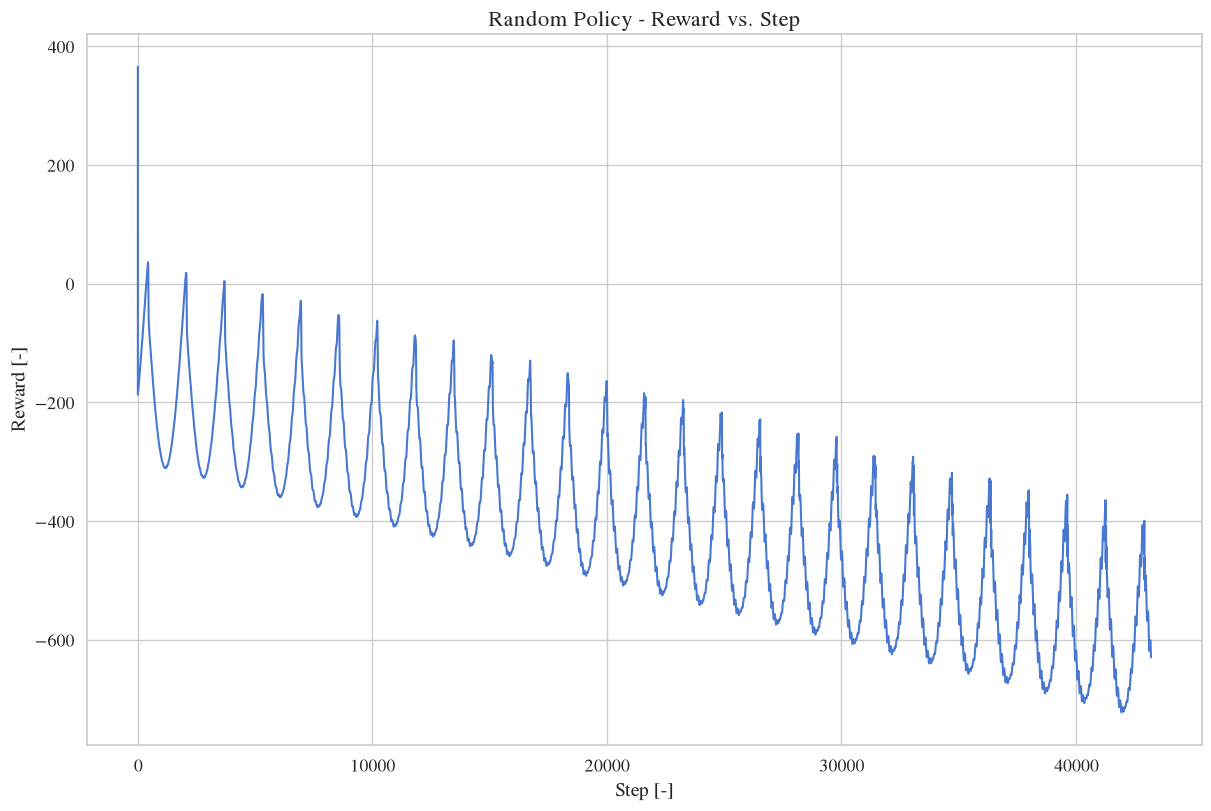

In [13]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Random Policy - Reward vs. Step")
ax.set_xlabel("Step [-]")
ax.set_ylabel("Reward [-]")
ax.plot(randomRewards)

fig.savefig(f"plots/{MODEL_NAME}_randomRewardStep.pdf", bbox_inches="tight")
plt.show()

### Relative Distance vs. Time

Shows the evolution of the relative distance between the sail and debris object.

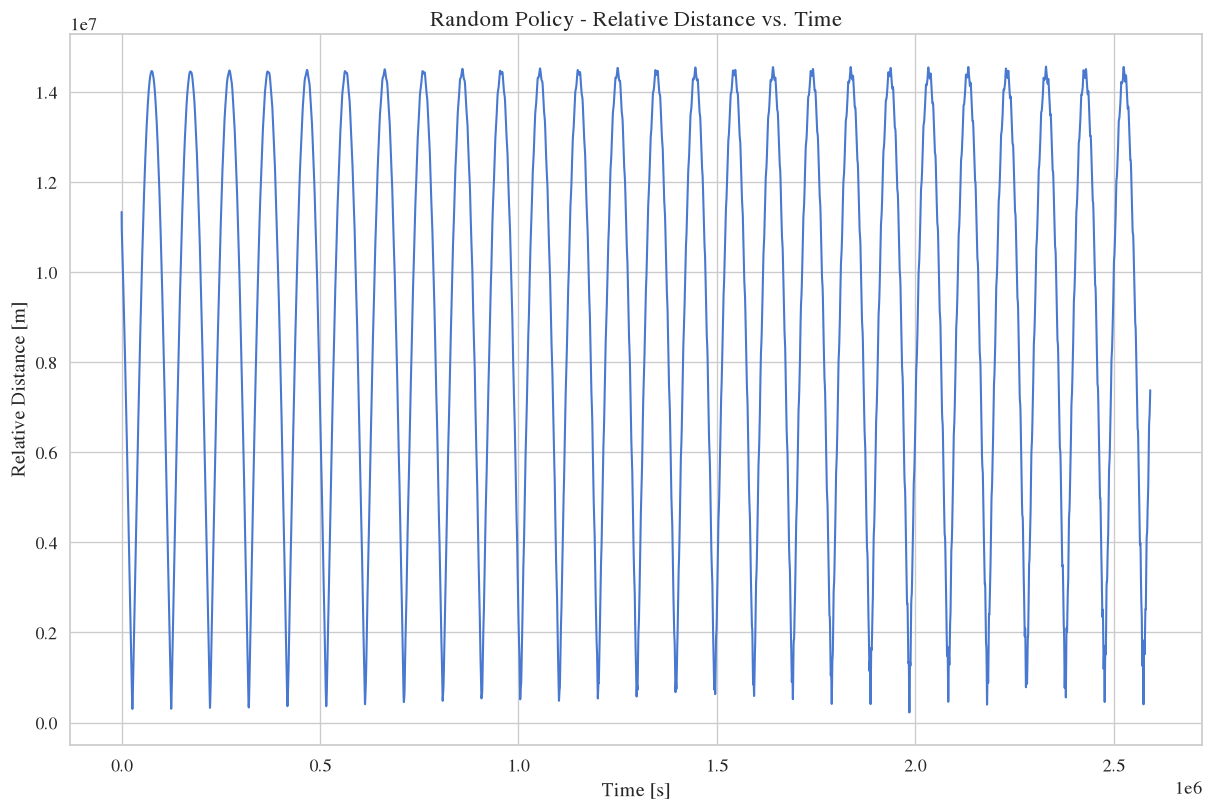

In [14]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Random Policy - Relative Distance vs. Time")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Relative Distance [m]")
ax.plot(randomTimes, randomRelDists)

fig.savefig(f"plots/{MODEL_NAME}_randomRelDists.pdf", bbox_inches="tight")
plt.show()

### Altitudes vs. Time

Shows the evolution of the sail and debris altitudes over time.

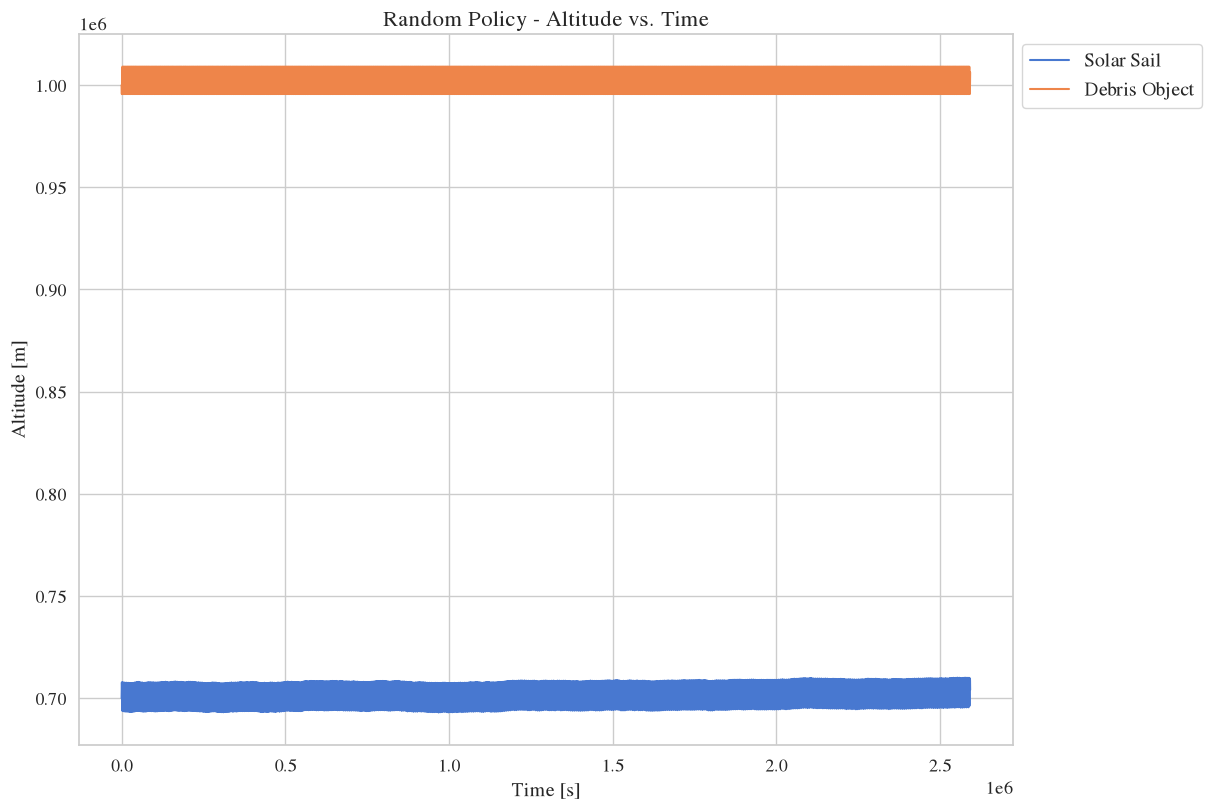

In [16]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Random Policy - Altitude vs. Time")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Altitude [m]")
ax.plot(randomTimes, randomSailAlts, label="Solar Sail")
ax.plot(randomTimes, randomDebrisAlts, label="Debris Object")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
fig.savefig(f"plots/{MODEL_NAME}_randomAltitudes.pdf", bbox_inches="tight")
plt.show()

### Control Angles vs. Time

Shows the evolution of the cone and clock angles over time.

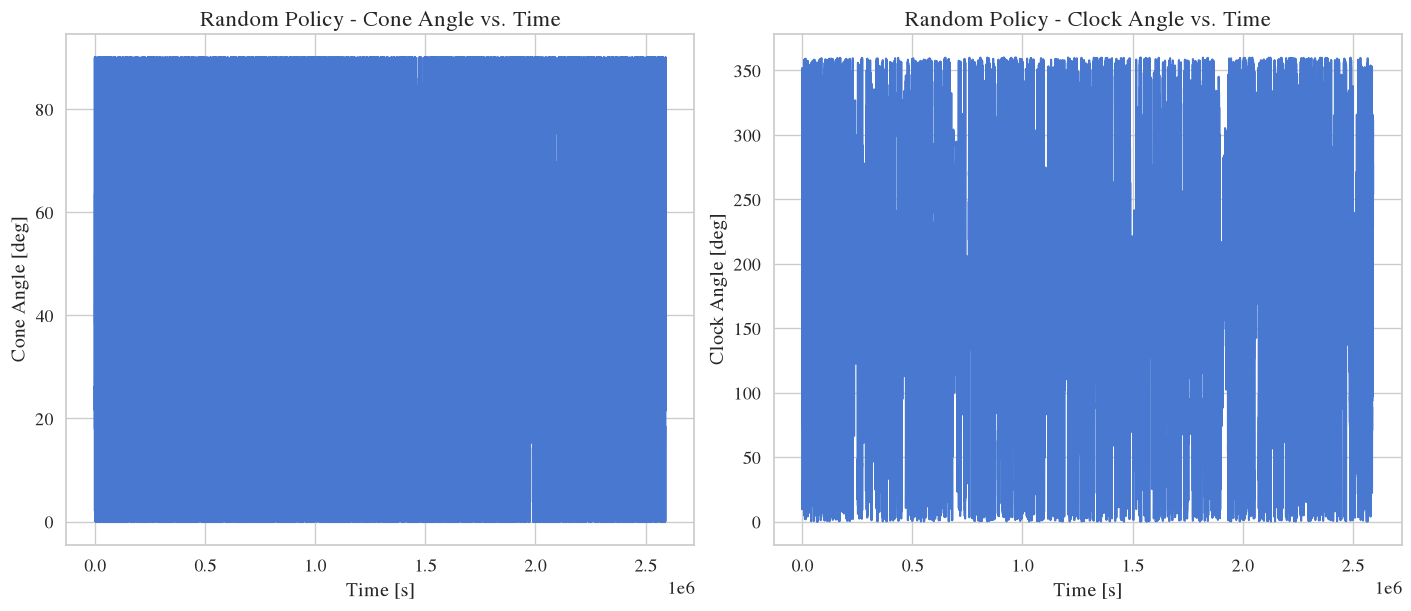

In [17]:
fig, (axCone, axClock) = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
axCone.set_title("Random Policy - Cone Angle vs. Time")
axCone.set_xlabel("Time [s]")
axCone.set_ylabel("Cone Angle [deg]")
axCone.plot(randomTimes, randomConeAngles)

axClock.set_title("Random Policy - Clock Angle vs. Time")
axClock.set_xlabel("Time [s]")
axClock.set_ylabel("Clock Angle [deg]")
axClock.plot(randomTimes, randomClockAngles)

fig.savefig(f"plots/{MODEL_NAME}_randomControlAngles.pdf", bbox_inches="tight")
plt.show()

## Initial Training

In [ ]:
trainModel(seed=INITIAL_SEED)

trainingData = load_results(f"trainingData/")
trainingData["steps"] = trainingData["l"].cumsum()
trainingRewards = trainingData["r"].to_numpy()
trainingLengths = trainingData["l"].to_numpy()
trainingSteps = trainingData["steps"].to_numpy()

### Reward vs. Episode

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Training - Reward vs. Episode")
ax.set_xlabel("Episode [-]")
ax.set_ylabel("Reward [-]")
ax.plot(trainingRewards)

fig.savefig(f"plots/{MODEL_NAME}_trainReward.pdf", bbox_inches="tight")
plt.show()

### Reward vs. Steps

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Training - Reward vs. Step")
ax.set_xlabel("Step [-]")
ax.set_xscale("log")
ax.set_ylabel("Reward [-]")
ax.plot(trainingSteps, trainingRewards)

fig.savefig(f"plots/{MODEL_NAME}_trainRewardStep.pdf", bbox_inches="tight")
plt.show()

### Episode Length

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Training - Episode Length")
ax.set_xlabel("Episode [-]")
ax.set_ylabel("Length [steps]")
ax.plot(trainingLengths)

fig.savefig(f"plots/{MODEL_NAME}_trainLength.pdf", bbox_inches="tight")
plt.show()

### Reward vs. Length

In [ ]:
successfulRuns = trainingRewards >= 100
alphas = np.linspace(0.1, 1.0, len(trainingRewards))

fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Training - Reward vs. Length")
ax.set_xlabel("Length [steps]")
ax.set_ylabel("Reward [-]")
ax.scatter(trainingLengths[successfulRuns], trainingRewards[successfulRuns], color="g", alpha=alphas[successfulRuns])
ax.scatter(trainingLengths[~successfulRuns], trainingRewards[~successfulRuns], color="r", alpha=alphas[~successfulRuns])
ax.axhline(200, ls="--", alpha=0.5, color="k", label="Success Threshold")

legendElements = [plt.Line2D([0], [0], marker="o", color="none", markerfacecolor="g", markeredgecolor="none", markersize=8, label="Successful Episode"),
                  plt.Line2D([0], [0], marker="o", color="none", markerfacecolor="r", markeredgecolor="none", markersize=8, label="Failed Episode"),
                  plt.Line2D([0], [0], ls="--", alpha=0.5, color="k", label="Success Threshold")]
ax.legend(handles=legendElements, loc="upper left", bbox_to_anchor=(1, 1))
fig.savefig(f"plots/{MODEL_NAME}_trainRewardLength.pdf", bbox_inches="tight")
plt.show()

## Hyperparameter Tuning

Fine-tuning the model by finding the best set of model parameters to carry out the training. The objective function that includes the hyperparameters to tune and the ranges to tune them in is defined.

In [ ]:
def objective(trial, tuningSeed: int, validationSeed: int, envName: str=ENVIRONMENT_NAME):
    """
        Function used to select a set of hyperparameters and run the model.
    """
    learningRate = trial.suggest_float("learning_rate", 1E-06, 1E-03, log=True)
    nSteps = trial.suggest_categorical("n_steps", [512, 1024, 2048, 4096])
    batchSize = trial.suggest_categorical("batch_size", [32, 64, 128, 256, 512])
    nEpochs = trial.suggest_categorical("n_epochs", [5, 10, 15, 20])
    discountFactor = trial.suggest_float("gamma", 0.8, 0.9997)
    gaeLambda = trial.suggest_float("gae_lambda", 0.9, 1.0)
    clipRange = trial.suggest_float("clip_range", 0.1, 0.3)
    normalizeAdv = trial.suggest_categorical("normalize_advantage", [True, False])
    entropyCoeff = trial.suggest_float("ent_coef", 0.0, 1E-02, log=True)
    valueCoeff = trial.suggest_float("vf_coef", 0.5, 1.0)

    env = gym.make(envName, maxTime=REDUCED_EPISODE_TIME)
    env.reset(seed=tuningSeed)

    model = PPO("MlpPolicy", env, learning_rate=learningRate, n_steps=nSteps, batch_size=batchSize, n_epochs=nEpochs, gamma=discountFactor, gae_lambda=gaeLambda, clip_range=clipRange, normalize_advantage=normalizeAdv, ent_coef=entropyCoeff, vf_coef=valueCoeff, seed=tuningSeed)
    model.learn(total_timesteps=int(REDUCED_EPISODE_TIME/TIME_STEP)*7, progress_bar=False)
    env.close()
    rewards, _ = testModel(model, validationSeed, tuning=True)

    return rewards.mean()

objectiveWithArgs = lambda trial: objective(trial, tuningSeed=TUNING_SEED, validationSeed=VALIDATION_SEED)

The objective is passed to a study that aims to maximize the mean reward.

In [ ]:
sampler = optuna.samplers.TPESampler(seed=TUNING_SEED, n_startup_trials=5)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objectiveWithArgs, n_trials=10)

The best parameters can then be examined.

In [ ]:
print(f"Best Mean Reward: {study.best_value:.5f}")
bestParams = study.best_params
print("Achieved with the following parameters:")
for param, val in bestParams.items():
    print(f"    {param}: {val}")

## Training the Tuned Model

In [ ]:
trainModel(seed=TRAINING_SEED, modelName=TUNED_MODEL_NAME, **bestParams)

tunedTrainingData = pd.read_csv(f"trainingData/{TUNED_MODEL_NAME}.monitor.csv", skiprows=1)
tunedTrainingData["steps"] = tunedTrainingData["l"].cumsum()
tunedTrainingRewards = tunedTrainingData["r"].to_numpy()
tunedTrainingLengths = tunedTrainingData["l"].to_numpy()
tunedTrainingSteps = tunedTrainingData["steps"].to_numpy()

### Reward vs. Episode

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Tuned Training - Reward vs. Episode")
ax.set_xlabel("Episode [-]")
ax.set_ylabel("Reward [-]")
ax.plot(tunedTrainingRewards)

fig.savefig(f"plots/{TUNED_MODEL_NAME}_trainReward.pdf", bbox_inches="tight")
plt.show()

### Reward vs. Step

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Tuned Training - Reward vs. Step")
ax.set_xlabel("Step [-]")
ax.set_xscale("log")
ax.set_ylabel("Reward [-]")
ax.plot(tunedTrainingSteps, tunedTrainingRewards)

fig.savefig(f"plots/{TUNED_MODEL_NAME}_trainRewardStep.pdf", bbox_inches="tight")
plt.show()

### Episode Length

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Tuned Training - Episode Length")
ax.set_xlabel("Episode [-]")
ax.set_ylabel("Length [steps]")
ax.plot(tunedTrainingLengths)

fig.savefig(f"plots/{TUNED_MODEL_NAME}_trainLength.pdf", bbox_inches="tight")
plt.show()

### Reward vs. Length

In [ ]:
successfulRuns = tunedTrainingRewards >= 100
alphas = np.linspace(0.1, 1.0, len(tunedTrainingRewards))

fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Tuned Training - Reward vs. Length")
ax.set_xlabel("Length [steps]")
ax.set_ylabel("Reward [-]")
ax.scatter(tunedTrainingLengths[successfulRuns], tunedTrainingRewards[successfulRuns], color="g", alpha=alphas[successfulRuns])
ax.scatter(tunedTrainingLengths[~successfulRuns], tunedTrainingRewards[~successfulRuns], color="r", alpha=alphas[~successfulRuns])
ax.axhline(200, ls="--", alpha=0.5, color="k", label="Success Threshold")

legendElements = [plt.Line2D([0], [0], marker="o", color="none", markerfacecolor="g", markeredgecolor="none", markersize=8, label="Successful Episode"),
                  plt.Line2D([0], [0], marker="o", color="none", markerfacecolor="r", markeredgecolor="none", markersize=8, label="Failed Episode"),
                  plt.Line2D([0], [0], ls="--", alpha=0.5, color="k", label="Success Threshold")]
ax.legend(handles=legendElements, loc="upper left", bbox_to_anchor=(1, 1))
fig.savefig(f"plots/{TUNED_MODEL_NAME}_trainRewardLength.pdf", bbox_inches="tight")
plt.show()

## Testing the Tuned Model